In [52]:
import numpy as np
import scipy as sp
import soundfile as sf
import torch
import torch.nn as nn

data, samplerate = sf.read('data/train_audio/grekis/XC474863.ogg')
data2, samplerate2 = sf.read('data/train_audio/grekis/XC390427.ogg')
data3, samplerate3 = sf.read('data/train_audio/grekis/XC358314.ogg')
data4, samplerate4 = sf.read('data/train_audio/grekis/XC486153.ogg')
print(data.shape)
print(samplerate)



(737280,)
32000


In [ ]:
import librosa
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
def process_data(data,samplerate, samples=500000, n_mels=128, n_fft=2048, hop_length=512):
    #window_length = 11
    #polyorder = 3
    #filtered = savgol_filter(data, window_length=window_length, polyorder=polyorder)
    #filtered = gaussian_filter1d(data, sigma=10)
    #resampled_data = sp.signal.resample(data, samples)
    mel_spec = librosa.feature.melspectrogram(y=data, sr=samplerate, 
                                              n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)

    # Convert to dB (log scale)  
    mel_spectrogram_db = librosa.amplitude_to_db(mel_spec, ref=np.max) 
    return mel_spectrogram_db

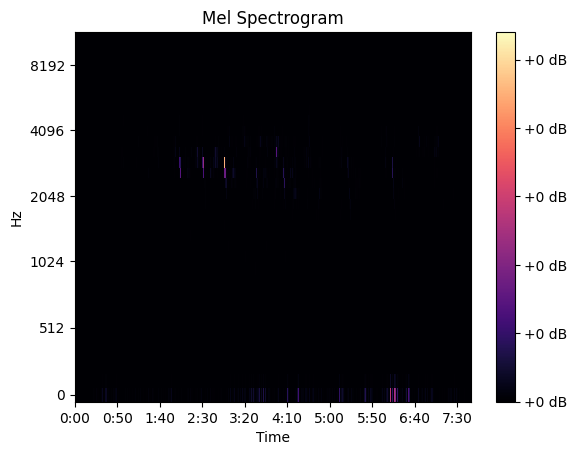

In [56]:
from matplotlib import pyplot as plt


# Compute the STFT
# f, t, Zxx = sp.signal.stft(data, fs=samplerate, window='hann', nperseg=256, noverlap=128)

# # Plot the STFT Magnitude
# plt.figure(figsize=(10, 6))
# plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
# plt.title('STFT Magnitude')
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [sec]')
# plt.colorbar(label='Magnitude')
# plt.show()

mel_spec = process_data(data3, samplerate4, n_mels=32, n_fft=256, hop_length=16)
librosa.display.specshow(mel_spec, y_axis='mel', x_axis='time');
plt.title('Mel Spectrogram');
plt.colorbar(format='%+2.0f dB');
plt.show()

# mel_spec2 = process_data(data2, samplerate2)
# librosa.display.specshow(mel_spec2, y_axis='mel', fmax=8000, x_axis='time');
# plt.title('Mel Spectrogram');
# plt.colorbar(format='%+2.0f dB');

# mel_spec3 = process_data(data3, samplerate3)
# librosa.display.specshow(mel_spec3, y_axis='mel', fmax=8000, x_axis='time');
# plt.title('Mel Spectrogram');
# plt.colorbar(format='%+2.0f dB');

In [30]:
fourier = np.fft.rfft(data)
fourier2 = np.fft.rfft(data2)
fourier3 = np.fft.rfft(data3)
print(fourier.shape)
print(fourier.real[:10])

(368641,)
[0.09176032 0.00025267 0.092545   0.01380226 0.08190364 0.02880291
 0.05918197 0.0551796  0.03713273 0.05951806]


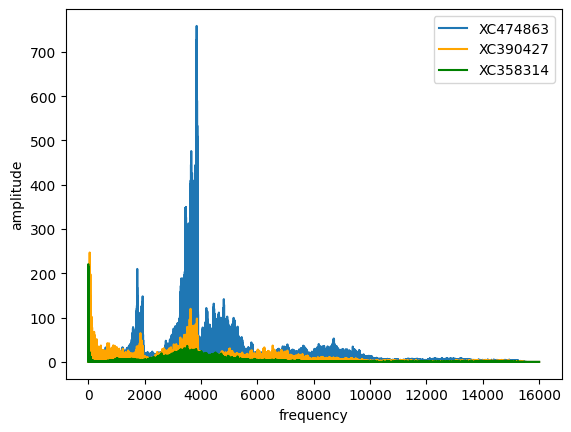

In [31]:
import matplotlib.pyplot as plt

w = np.linspace(0, samplerate//2, len(fourier))
w2 = np.linspace(0, samplerate2//2, len(fourier2))
w3 = np.linspace(0, samplerate3//2, len(fourier3))
fourier_to_plot = np.abs(fourier.real)
fourier_to_plot2 = np.abs(fourier2.real)
fourier_to_plot3 = np.abs(fourier3.real)
plt.plot(w, fourier_to_plot, label='XC474863')
plt.plot(w2, fourier_to_plot2, label='XC390427', color='orange')
plt.plot(w3, fourier_to_plot3, label='XC358314', color='green')
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.legend()
plt.show()

In [ ]:
# compute frequency associated
# with coefficients
freqs = np.fft.rfftfreq(len(data), d=1/samplerate)
plt.plot(freqs, fourier_to_plot)    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()
print(freqs.shape)

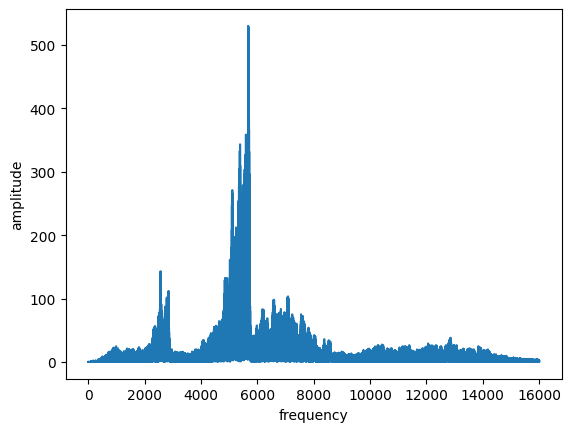

fourier bins: (250001,)
og size: 3.8147125244140625 MB


In [34]:
resampled_data = sp.signal.resample(data, 500000)
fourier = np.fft.rfft(resampled_data)
freqs = np.fft.rfftfreq(len(resampled_data), d=1/samplerate)
plt.plot(freqs, np.abs(fourier))    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()
print(f'fourier bins: {fourier.shape}')
print(f'og size: {fourier.nbytes/(1024**2)} MB')
# fourier = np.abs(fourier)
# fourier = fourier.astype(np.float16, copy=False)
# print(f'new size: {fourier.nbytes/(1024**2)} MB')
# plt.plot(freqs, fourier)    
# plt.xlabel('frequency')
# plt.ylabel('amplitude')
# plt.show()



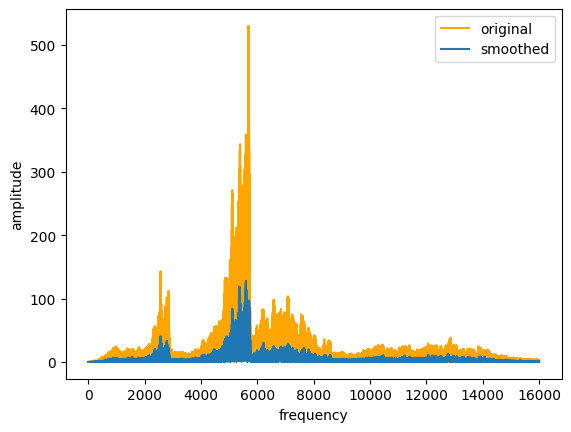

In [35]:
from scipy.ndimage import gaussian_filter1d

smoothed_fourier = gaussian_filter1d(fourier, sigma=2)
plt.plot(freqs, np.abs(fourier), label='original', color='orange')
plt.plot(freqs, np.abs(smoothed_fourier), label='smoothed')
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.legend()
plt.show()

In [ ]:
# The maximum frequency is half the sample rate
points_per_freq = len(data) / (samplerate / 2)

nyquist_freq = samplerate / 2
print(f"Nyquist frequency: {nyquist_freq} Hz")

fft_bins = len(data)/2
resolution = nyquist_freq / fft_bins
print(f"FFT resolution: {resolution} Hz per bin")

bins = 0
for i in range(0, int(nyquist_freq), 10):
    idx = int(points_per_freq * i)
    print(f"Frequency: {i} Hz, Index: {idx}")
    bins += 1
print(f"Total bins: {bins}")

In [ ]:
X_train = fourier_to_plot
y_train = np.array([0])  # dummy label

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 256
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
input_size = X_train.shape[1]
hidden_units = [input_size, input_size//2, input_size//4]

all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(class_le.classes_)))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

In [ ]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from matplotlib import pyplot as plt

with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)
print(balanced_accuracy_score(y_test, y_pred))